In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from app.utils.gpt_parser import canonical_portfolio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from app.core.calculations.returns.calculator import ReturnsCalculator, PortfolioReturnsCalculator
from app.core.calculations.performance.calculator import PerformanceCalculator
from app.core.calculations.risk.calculator import RiskCalculator
from app.repositories.price_data import get_price_data_daily, get_dividends_series
from app.repositories.price_data import fetch_bulk_price_data_for_tickers
import matplotlib.pyplot as plt
# Fetch industry and sub-industry data for all tickers
from app.db.core.db_config import MarketSession, ProphitAltsSession
from app.db.core.models.market_data_models import Ticker
from app.core.agentic_framework.tool_lib.portfolio_tools.performance import calculate_portfolio_performance



In [ ]:

x = {"portfolio": [{"ticker": "NVDA", "allocation": 0.08, "position": "long", "changes_from_original": "Increased (0.065 to 0.08) to anchor for growth and alpha."}, {"ticker": "APP", "allocation": 0.05, "position": "long", "changes_from_original": "Increased (0.042 to 0.05) based on top risk-adjusted return."}, {"ticker": "AVGO", "allocation": 0.05, "position": "long", "changes_from_original": "Increased (0.034 to 0.05) for quality/growth balance."}, {"ticker": "PLTR", "allocation": 0.03, "position": "long", "changes_from_original": "Slight trim (0.027 to 0.03) for balanced tech exposure."}, {"ticker": "BSX", "allocation": 0.05, "position": "long", "changes_from_original": "Proportional trim (0.051 to 0.05) for risk parity."}, {"ticker": "NRG", "allocation": 0.04, "position": "long", "changes_from_original": "Reduced slightly (0.055 to 0.04) for scenario sizing."}, {"ticker": "JPM", "allocation": 0.04, "position": "long", "changes_from_original": "Adjusted (0.043 to 0.04) for risk budget and financials mix."}, {"ticker": "EQIX", "allocation": 0.04, "position": "long", "changes_from_original": "Right-sized (0.081 to 0.04) to reduce REIT/correlation risk."}, {"ticker": "SGDM", "allocation": 0.03, "position": "long", "changes_from_original": "Up (0.016 to 0.03) to keep gold/hedge exposure robust."}, {"ticker": "SLVR", "allocation": 0.03, "position": "long", "changes_from_original": "Down (0.036 to 0.03) to balance commodities within risk budget."}, {"ticker": "GREK", "allocation": 0.025, "position": "long", "changes_from_original": "Minor increase (0.021 to 0.025) for EM/momentum tilt."}, {"ticker": "VCSH", "allocation": 0.03, "position": "long", "changes_from_original": "No significant change from previous allocation."}, {"ticker": "IGSB", "allocation": 0.03, "position": "long", "changes_from_original": "No significant change from previous allocation."}, {"ticker": "LLY", "allocation": 0.025, "position": "long", "changes_from_original": "Added: Best-in-class pharma, high Sharpe, growth, and alpha potential added for defensive growth quality."}, {"ticker": "CL", "allocation": 0.02, "position": "long", "changes_from_original": "Added: Ultra-low beta/high ROE, major staple added for drawdown minimization."}, {"ticker": "CLX", "allocation": 0.02, "position": "long", "changes_from_original": "Added: High ROE, defensive blue-chip replaces high-beta/volatility exposures."}, {"ticker": "KMB", "allocation": 0.015, "position": "long", "changes_from_original": "Added: Low beta, quality staple, improves defensive tilt and lowers overall risk."}]}
# portfolio = {'APP': {'allocation': 0.0006, 'position': 'long'}, 'ARM': {'allocation': 0.0035, 'position': 'long'}, 'AVGO': {'allocation': 0.0222, 'position': 'long'}, 'BSX': {'allocation': 0.0792, 'position': 'long'}, 'CEG': {'allocation': 0.0068, 'position': 'long'}, 'CMS': {'allocation': 0.1169, 'position': 'long'}, 'DGNX': {'allocation': 0.0034, 'position': 'long'}, 'EIS': {'allocation': 0.082, 'position': 'long'}, 'EQIX': {'allocation': 0.0721, 'position': 'long'}, 'EXOD': {'allocation': 0.0158, 'position': 'long'}, 'JPM': {'allocation': 0.075, 'position': 'long'}, 'MU': {'allocation': 0.0039, 'position': 'long'}, 'NLR': {'allocation': 0.0509, 'position': 'long'}, 'NRG': {'allocation': 0.0204, 'position': 'long'}, 'NVDA': {'allocation': 0.0233, 'position': 'long'}, 'PLTR': {'allocation': 0.0072, 'position': 'long'}, 'SGDM': {'allocation': 0.08, 'position': 'long'}, 'SLVR': {'allocation': 0.0515, 'position': 'long'}, 'STAG': {'allocation': 0.0819, 'position': 'long'}, 'TRNO': {'allocation': 0.0737, 'position': 'long'}, 'VCSH': {'allocation': 0.1298, 'position': 'long'}}
# portfolio = canonical_portfolio(x)

In [12]:
# Convert portfolio to weights dict (negative for shorts)
weights = {}
for ticker, data in portfolio.items():
    position = data["position"]
    allocation = data["allocation"]
    
    if position.lower() == "short":
        weights[ticker] = -allocation
    else:
        weights[ticker] = allocation

print(f"Portfolio has {len(weights)} positions")
print(f"Long positions: {sum(1 for w in weights.values() if w > 0)}")
print(f"Short positions: {sum(1 for w in weights.values() if w < 0)}")
print(f"Net exposure: {sum(weights.values()):.2%}")
print(f"Gross exposure: {sum(abs(w) for w in weights.values()):.2%}")
print()


Portfolio has 21 positions
Long positions: 21
Short positions: 0
Net exposure: 100.01%
Gross exposure: 100.01%



The cell below is how the portfolio will have performed from the day it was built in the sim to today

In [13]:
# Fetch daily price data in bulk
start_date = datetime(2024, 9, 30)
end_date = datetime.now()

start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

print("Fetching daily price data in bulk (including SPY benchmark)...")
all_tickers = list(weights.keys()) + ["SPY"]

ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    start_date_str, 
    end_date_str, 
    frequency='daily'
)

print(f"Successfully fetched daily data for {len(ticker_closes)} tickers\n")

# Calculate portfolio daily returns
ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(ticker_closes[t])
    for t in weights if t in ticker_closes
}

# Use dropna=True to ensure clean data for beta calculation
portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics
annualized_return = ReturnsCalculator.annualized_return(portfolio_daily_returns, trading_days=252)
annual_volatility = RiskCalculator.annualized_volatility(portfolio_daily_returns, trading_days=252)
sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha vs SPY (already fetched in bulk)
if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    alpha = PerformanceCalculator.alpha_jensen(
        portfolio_daily_returns,
        spy_returns,
        periods_per_year=252
    )
    # Calculate beta vs SPY using RiskCalculator
    beta = RiskCalculator.beta(
        asset_daily_returns=portfolio_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    print("SPY benchmark data not available")
    alpha = np.nan
    beta = np.nan

# Print results
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {annualized_return:>8.2%}")
print(f"Annual Volatility:     {annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {alpha:>8.2%}")
print(f"Beta vs SPY:           {beta:>8.2f}")
print("=" * 60)

Fetching daily price data in bulk (including SPY benchmark)...
Successfully fetched daily data for 22 tickers

PORTFOLIO PERFORMANCE METRICS
Annualized Return:       37.68%
Annual Volatility:       15.32%
Sharpe Ratio:              1.91
Alpha vs SPY:            20.08%
Beta vs SPY:               0.68


In [5]:
# ACTIVE MANAGEMENT STRATEGY
# Apply rebalancing rules based on position performance
print("=" * 60)
print("APPLYING ACTIVE MANAGEMENT STRATEGY")
print("=" * 60)
print("Rules:")
print("  1. If position hits -5% cumulative return: cut in half, move to best performer")
print("  2. If position hits -10% cumulative return: close entire position, move to best performer")
print("=" * 60)

# Initialize managed weights (copy original weights)
managed_weights = weights.copy()
initial_weights = weights.copy()

# Track rebalancing events
rebalancing_events = []

# Get all dates from portfolio returns
dates = portfolio_daily_returns.index

# Calculate cumulative returns for each position and align to portfolio dates
position_cumulative_returns = {}
for ticker in weights.keys():
    if ticker in ticker_price_returns:
        # Calculate cumulative returns
        cum_rets = (1 + ticker_price_returns[ticker]).cumprod()
        # Reindex to portfolio dates and forward fill missing values
        position_cumulative_returns[ticker] = cum_rets.reindex(dates, method='ffill')
    else:
        # If no price data, assume flat performance
        position_cumulative_returns[ticker] = pd.Series(1.0, index=dates)

# Track managed weights over time
managed_weights_history = pd.DataFrame(index=dates, columns=list(weights.keys()), dtype=float)
managed_weights_history.iloc[0] = pd.Series(managed_weights)

# Track which positions have been triggered at each level
triggered_5pct = {ticker: False for ticker in weights.keys()}
triggered_10pct = {ticker: False for ticker in weights.keys()}

# Iterate through each day and check for rebalancing triggers
for i, date in enumerate(dates[1:], start=1):
    # Copy previous day's weights
    managed_weights_history.iloc[i] = managed_weights_history.iloc[i-1]
    
    for ticker in weights.keys():
        if ticker not in ticker_price_returns:
            continue
            
        # Get cumulative return since inception
        cum_return = (position_cumulative_returns[ticker].loc[date] - 1.0)
        current_weight = managed_weights_history.loc[date, ticker]
        
        # Skip if position is already closed
        if abs(current_weight) < 0.001:
            continue
        
        # Check for -10% trigger (close entire position)
        if cum_return <= -0.10 and not triggered_10pct[ticker]:
            # Find best performing position (highest cumulative return)
            eligible_tickers = [t for t in weights.keys() if t in ticker_price_returns and abs(managed_weights_history.loc[date, t]) > 0.001]
            if not eligible_tickers:
                continue
            best_performer = max(
                eligible_tickers,
                key=lambda t: position_cumulative_returns[t].loc[date] if date in position_cumulative_returns[t].index else 1.0
            )
            
            # Transfer entire position to best performer
            transferred_weight = current_weight
            managed_weights_history.loc[date:, ticker] = 0
            managed_weights_history.loc[date:, best_performer] += transferred_weight
            
            triggered_10pct[ticker] = True
            triggered_5pct[ticker] = True  # Also mark -5% as triggered
            
            rebalancing_events.append({
                'date': date,
                'ticker': ticker,
                'action': 'CLOSE',
                'cum_return': cum_return,
                'weight_transferred': transferred_weight,
                'to_ticker': best_performer
            })
            
        # Check for -5% trigger (cut in half)
        elif cum_return <= -0.05 and not triggered_5pct[ticker] and not triggered_10pct[ticker]:
            # Find best performing position
            eligible_tickers = [t for t in weights.keys() if t in ticker_price_returns and abs(managed_weights_history.loc[date, t]) > 0.001]
            if not eligible_tickers:
                continue
            best_performer = max(
                eligible_tickers,
                key=lambda t: position_cumulative_returns[t].loc[date] if date in position_cumulative_returns[t].index else 1.0
            )
            
            # Transfer half of position to best performer
            transferred_weight = current_weight / 2
            managed_weights_history.loc[date:, ticker] -= transferred_weight
            managed_weights_history.loc[date:, best_performer] += transferred_weight
            
            triggered_5pct[ticker] = True
            
            rebalancing_events.append({
                'date': date,
                'ticker': ticker,
                'action': 'CUT_HALF',
                'cum_return': cum_return,
                'weight_transferred': transferred_weight,
                'to_ticker': best_performer
            })

# Print rebalancing events
print(f"\nTotal Rebalancing Events: {len(rebalancing_events)}")
print()
for event in rebalancing_events:
    print(f"{event['date'].strftime('%Y-%m-%d')}: {event['action']:10s} {event['ticker']:6s} "
          f"(Return: {event['cum_return']:>7.2%}) → Transfer {event['weight_transferred']:>6.2%} to {event['to_ticker']}")

# Calculate managed portfolio returns using dynamic weights
managed_daily_returns = pd.Series(0.0, index=dates)

for i, date in enumerate(dates):
    day_return = 0.0
    for ticker in weights.keys():
        if ticker in ticker_price_returns and date in ticker_price_returns[ticker].index:
            weight = managed_weights_history.loc[date, ticker]
            ticker_return = ticker_price_returns[ticker].loc[date]
            day_return += weight * ticker_return
    managed_daily_returns.loc[date] = day_return

# Calculate managed performance metrics
managed_annualized_return = ReturnsCalculator.annualized_return(managed_daily_returns, trading_days=252)
managed_annual_volatility = RiskCalculator.annualized_volatility(managed_daily_returns, trading_days=252)
managed_sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    managed_daily_returns, 
    periods_per_year=252
)

if "SPY" in ticker_closes:
    managed_alpha = PerformanceCalculator.alpha_jensen(
        managed_daily_returns,
        spy_returns,
        rf_annual=0.04,
        periods_per_year=252
    )
    managed_beta = RiskCalculator.beta(
        asset_daily_returns=managed_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    managed_alpha = np.nan
    managed_beta = np.nan

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON: UNMANAGED vs MANAGED")
print("=" * 60)
print(f"{'Metric':<25s} {'Unmanaged':>15s} {'Managed':>15s} {'Difference':>15s}")
print("-" * 60)
print(f"{'Annualized Return':<25s} {annualized_return:>14.2%} {managed_annualized_return:>14.2%} {managed_annualized_return-annualized_return:>14.2%}")
print(f"{'Annual Volatility':<25s} {annual_volatility:>14.2%} {managed_annual_volatility:>14.2%} {managed_annual_volatility-annual_volatility:>14.2%}")
print(f"{'Sharpe Ratio':<25s} {sharpe_ratio:>14.2f} {managed_sharpe_ratio:>14.2f} {managed_sharpe_ratio-sharpe_ratio:>14.2f}")
print(f"{'Alpha vs SPY':<25s} {alpha:>14.2%} {managed_alpha:>14.2%} {managed_alpha-alpha:>14.2%}")
print(f"{'Beta vs SPY':<25s} {beta:>14.2f} {managed_beta:>14.2f} {managed_beta-beta:>14.2f}")
print("=" * 60)


APPLYING ACTIVE MANAGEMENT STRATEGY
Rules:
  1. If position hits -5% cumulative return: cut in half, move to best performer
  2. If position hits -10% cumulative return: close entire position, move to best performer

Total Rebalancing Events: 20

2024-10-07: CUT_HALF   CL     (Return:  -5.05%) → Transfer  1.00% to APP
2024-10-14: CUT_HALF   GREK   (Return:  -5.65%) → Transfer  1.25% to PLTR
2024-10-17: CUT_HALF   NRG    (Return:  -5.60%) → Transfer  2.00% to PLTR
2024-10-29: CUT_HALF   KMB    (Return:  -5.27%) → Transfer  0.75% to APP
2024-10-31: CUT_HALF   LLY    (Return:  -6.38%) → Transfer  1.25% to APP
2024-11-01: CLOSE      CL     (Return: -10.10%) → Transfer  1.00% to APP
2024-11-06: CLOSE      LLY    (Return: -12.32%) → Transfer  1.25% to APP
2024-11-11: CUT_HALF   SGDM   (Return:  -6.88%) → Transfer  1.50% to APP
2024-11-15: CLOSE      SGDM   (Return: -10.01%) → Transfer  1.50% to APP
2024-11-19: CLOSE      GREK   (Return: -11.25%) → Transfer  1.25% to APP
2024-11-20: CUT_HALF 

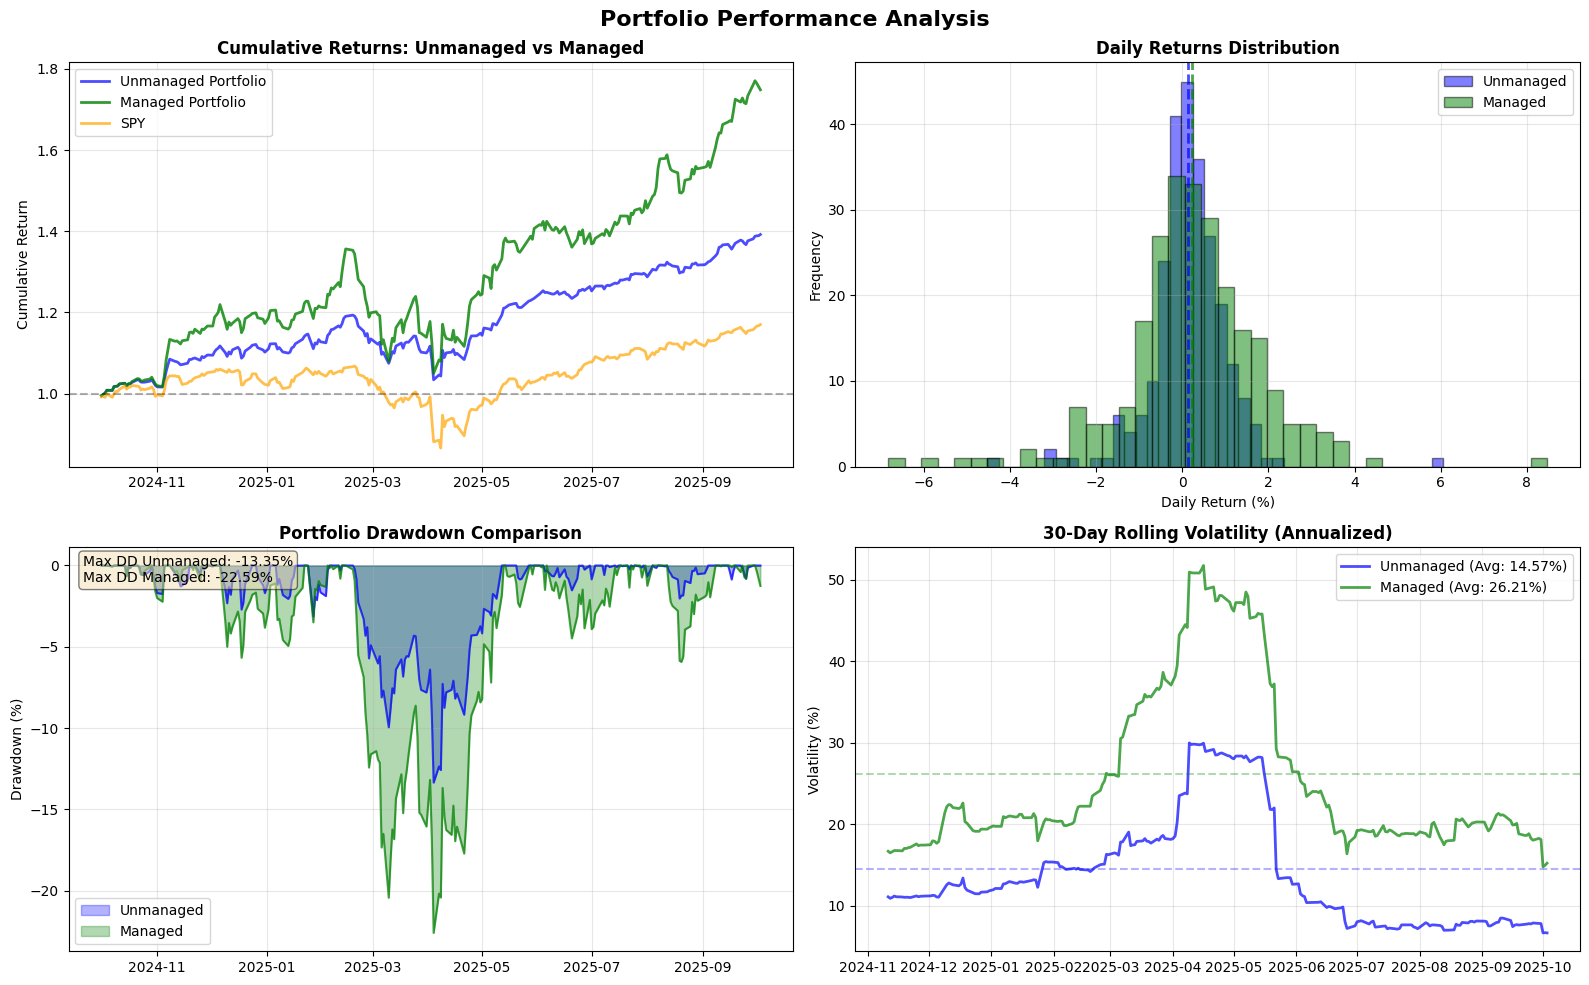

In [6]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance Analysis', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs Managed vs SPY
ax1 = axes[0, 0]
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
managed_cumulative = (1 + managed_daily_returns).cumprod()

ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Unmanaged Portfolio', alpha=0.7)
ax1.plot(managed_cumulative.index, managed_cumulative.values, 
         linewidth=2, color='green', label='Managed Portfolio', alpha=0.8)

if "SPY" in ticker_closes:
    spy_cumulative = (1 + spy_returns).cumprod()
    aligned_spy = spy_cumulative.reindex(portfolio_cumulative.index).ffill()
    ax1.plot(portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns: Unmanaged vs Managed', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution - Comparison
ax2 = axes[0, 1]
ax2.hist(portfolio_daily_returns.dropna() * 100, bins=40, alpha=0.5, 
         color='blue', edgecolor='black', label='Unmanaged')
ax2.hist(managed_daily_returns.dropna() * 100, bins=40, alpha=0.5, 
         color='green', edgecolor='black', label='Managed')
ax2.axvline(portfolio_daily_returns.mean() * 100, color='blue', 
            linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(managed_daily_returns.mean() * 100, color='green', 
            linestyle='--', linewidth=2, alpha=0.7)
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart - Comparison
ax3 = axes[1, 0]
running_max = portfolio_cumulative.cummax()
drawdown = (portfolio_cumulative / running_max - 1.0) * 100
managed_running_max = managed_cumulative.cummax()
managed_drawdown = (managed_cumulative / managed_running_max - 1.0) * 100

ax3.fill_between(drawdown.index, drawdown.values, 0, 
                  alpha=0.3, color='blue', label='Unmanaged')
ax3.plot(drawdown.index, drawdown.values, linewidth=1.5, color='blue', alpha=0.7)
ax3.fill_between(managed_drawdown.index, managed_drawdown.values, 0, 
                  alpha=0.3, color='green', label='Managed')
ax3.plot(managed_drawdown.index, managed_drawdown.values, linewidth=1.5, color='green', alpha=0.7)

ax3.set_title('Portfolio Drawdown Comparison', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
ax3.legend()
max_dd = drawdown.min()
managed_max_dd = managed_drawdown.min()
ax3.text(0.02, 0.98, f'Max DD Unmanaged: {max_dd:.2f}%\nMax DD Managed: {managed_max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day) - Comparison
ax4 = axes[1, 1]
rolling_vol = portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100
managed_rolling_vol = managed_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

ax4.plot(rolling_vol.index, rolling_vol.values, linewidth=2, color='blue', 
         label=f'Unmanaged (Avg: {annual_volatility*100:.2f}%)', alpha=0.7)
ax4.plot(managed_rolling_vol.index, managed_rolling_vol.values, linewidth=2, color='green',
         label=f'Managed (Avg: {managed_annual_volatility*100:.2f}%)', alpha=0.7)
ax4.axhline(y=annual_volatility * 100, color='blue', linestyle='--', alpha=0.3)
ax4.axhline(y=managed_annual_volatility * 100, color='green', linestyle='--', alpha=0.3)
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


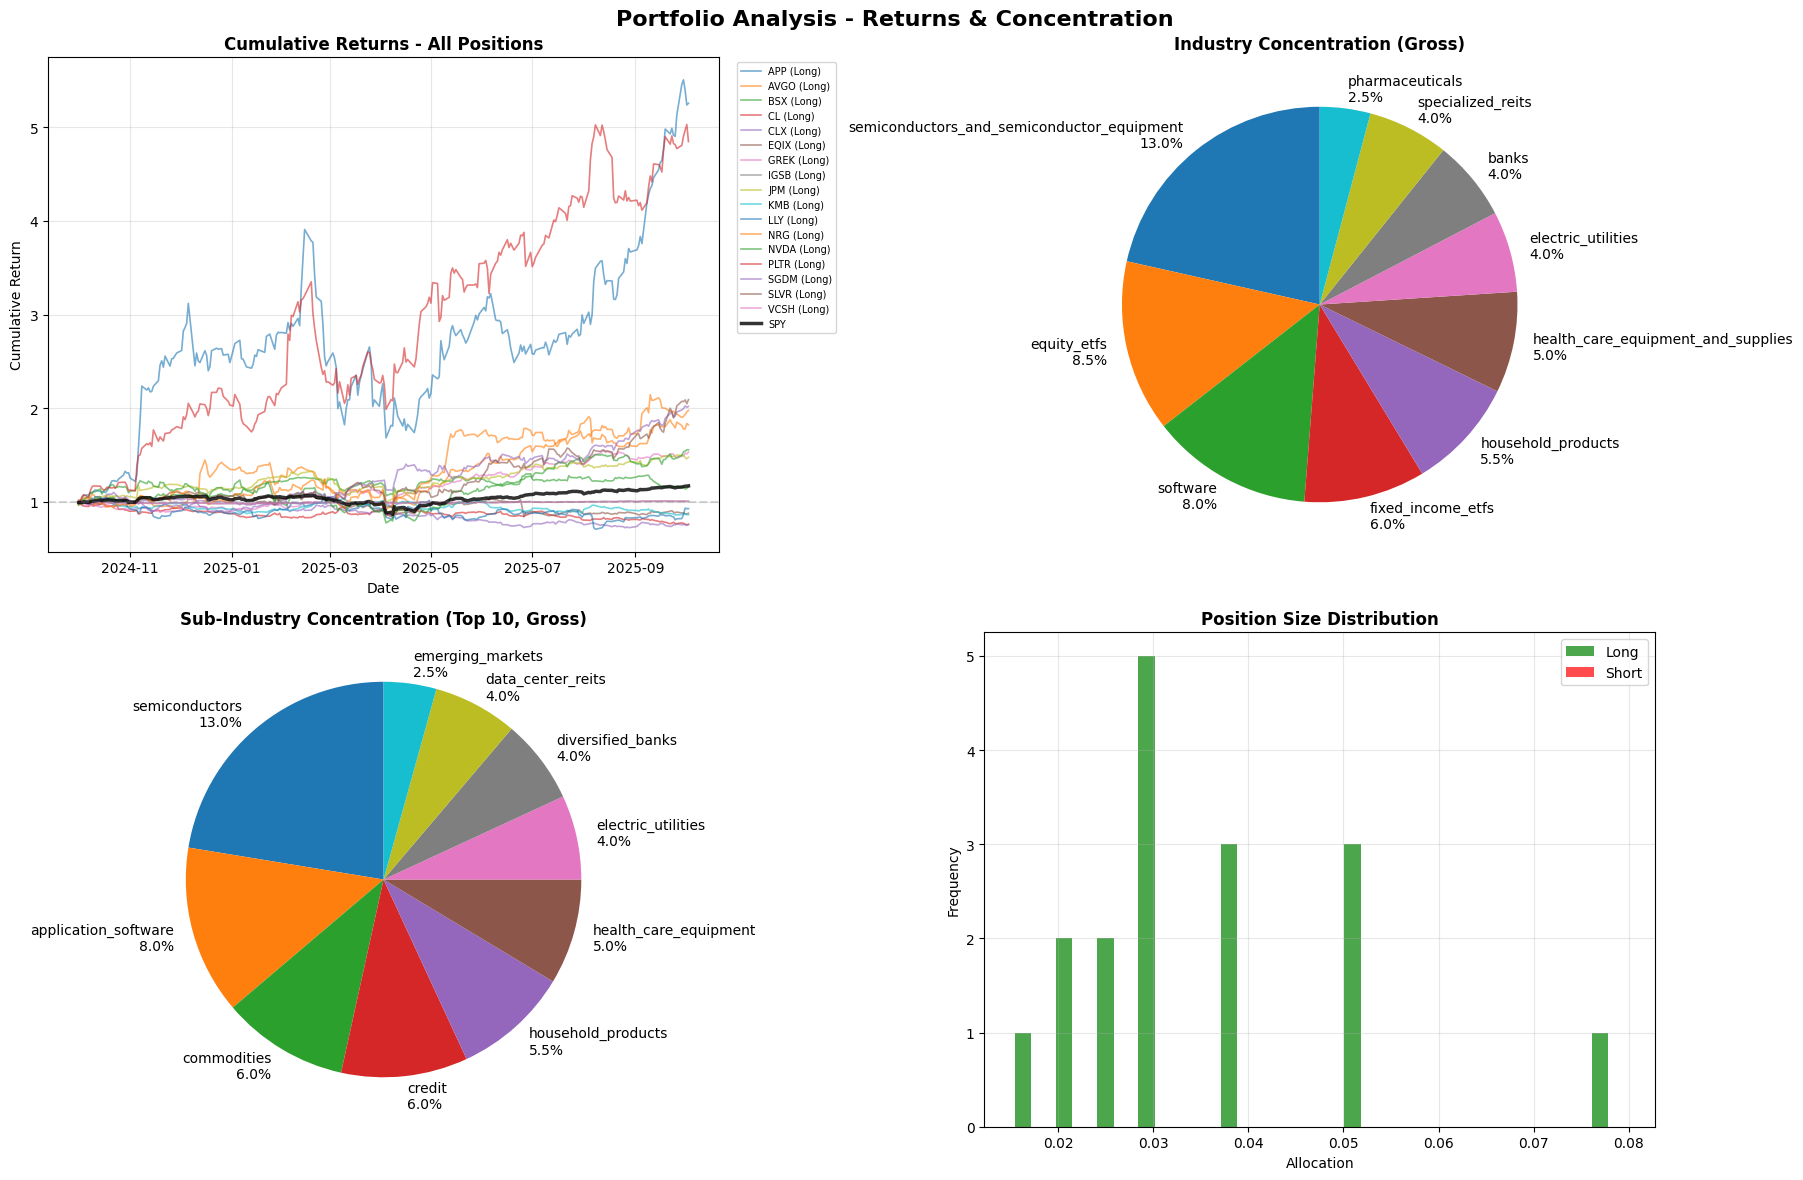

In [7]:
industry_data = {}
sub_industry_data = {}

with MarketSession() as session:
    for ticker in weights.keys():
        ticker_obj = session.query(Ticker).filter(Ticker.ticker == ticker.upper()).first()
        if ticker_obj:
            industry_data[ticker] = ticker_obj.industry
            sub_industry_data[ticker] = ticker_obj.sub_industry

# Calculate concentration by industry and sub-industry
industry_concentration = {}
sub_industry_concentration = {}

for ticker, allocation in weights.items():
    abs_allocation = abs(allocation)
    
    industry = industry_data.get(ticker, 'Unknown')
    if industry:
        industry_concentration[industry] = industry_concentration.get(industry, 0) + abs_allocation
    
    sub_industry = sub_industry_data.get(ticker, 'Unknown')
    if sub_industry:
        sub_industry_concentration[sub_industry] = sub_industry_concentration.get(sub_industry, 0) + abs_allocation

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Portfolio Analysis - Returns & Concentration', fontsize=16, fontweight='bold')

# 1. Cumulative returns of all positions
ax1 = axes[0, 0]
for ticker in sorted(weights.keys()):
    if ticker in ticker_price_returns:
        cumulative_returns = (1 + ticker_price_returns[ticker]).cumprod()
        position_type = portfolio[ticker]['position']
        
        if position_type.lower() == 'short':
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    linestyle='--', alpha=0.5, linewidth=1.2, label=f"{ticker} (Short)")
        else:
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    alpha=0.6, linewidth=1.2, label=f"{ticker} (Long)")

if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    spy_cumulative = (1 + spy_returns).cumprod()
    ax1.plot(spy_cumulative.index, spy_cumulative.values, 
            linewidth=2.5, color='black', label='SPY', alpha=0.8)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Returns - All Positions', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. Industry concentration pie chart
ax2 = axes[0, 1]
if industry_concentration:
    labels = [f"{k}\n{v:.1%}" for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    sizes = [v for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    ax2.pie(sizes, labels=labels, autopct='', startangle=90)
    ax2.set_title('Industry Concentration (Gross)', fontweight='bold')

# 3. Sub-industry concentration pie chart
ax3 = axes[1, 0]
if sub_industry_concentration:
    # Limit to top 10 for readability
    sorted_sub = sorted(sub_industry_concentration.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [f"{k}\n{v:.1%}" for k, v in sorted_sub]
    sizes = [v for k, v in sorted_sub]
    ax3.pie(sizes, labels=labels, autopct='', startangle=90)
    ax3.set_title('Sub-Industry Concentration (Top 10, Gross)', fontweight='bold')

# 4. Position size distribution
ax4 = axes[1, 1]
long_weights = [v for v in weights.values() if v > 0]
short_weights = [abs(v) for v in weights.values() if v < 0]
ax4.hist([long_weights, short_weights], bins=15, label=['Long', 'Short'], alpha=0.7, color=['green', 'red'])
ax4.set_title('Position Size Distribution', fontweight='bold')
ax4.set_xlabel('Allocation')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


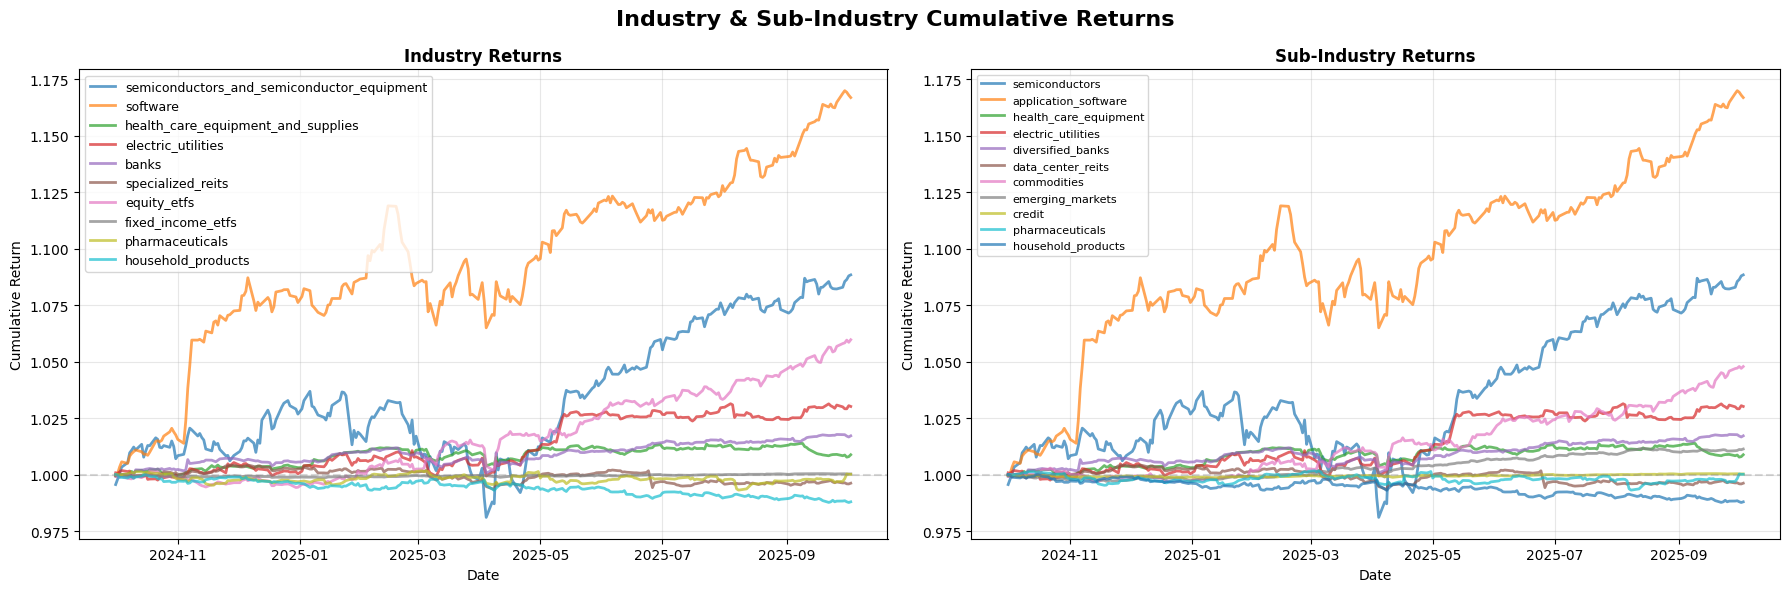

In [8]:
# Calculate industry and sub-industry level returns
# Group tickers by industry
industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        industry = industry_data.get(ticker)
        if industry:
            if industry not in industry_groups:
                industry_groups[industry] = {}
            industry_groups[industry][ticker] = allocation

# Group tickers by sub-industry
sub_industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        sub_industry = sub_industry_data.get(ticker)
        if sub_industry:
            if sub_industry not in sub_industry_groups:
                sub_industry_groups[sub_industry] = {}
            sub_industry_groups[sub_industry][ticker] = allocation

# Calculate industry-level returns
industry_returns = {}
for industry, tickers_weights in industry_groups.items():
    industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    industry_returns[industry] = industry_daily_returns

# Calculate sub-industry-level returns
sub_industry_returns = {}
for sub_industry, tickers_weights in sub_industry_groups.items():
    sub_industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    sub_industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        sub_industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    sub_industry_returns[sub_industry] = sub_industry_daily_returns

# Create two graphs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Industry & Sub-Industry Cumulative Returns', fontsize=16, fontweight='bold')

# 1. Industry returns
ax1 = axes[0]
for industry, returns in industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax1.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=industry)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Industry Returns', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Sub-industry returns
ax2 = axes[1]
for sub_industry, returns in sub_industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax2.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=sub_industry)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax2.set_title('Sub-Industry Returns', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Fetching 2 years of prior data: 2022-09-30 to 2024-09-30
Successfully fetched prior data for 17 tickers

PRIOR PERIOD (2022-09-30 to 2024-09-30) PERFORMANCE METRICS
Annualized Return:       39.17%
Annual Volatility:       11.78%
Sharpe Ratio:              2.53
Alpha vs SPY:            15.74%
Beta vs SPY:               0.68


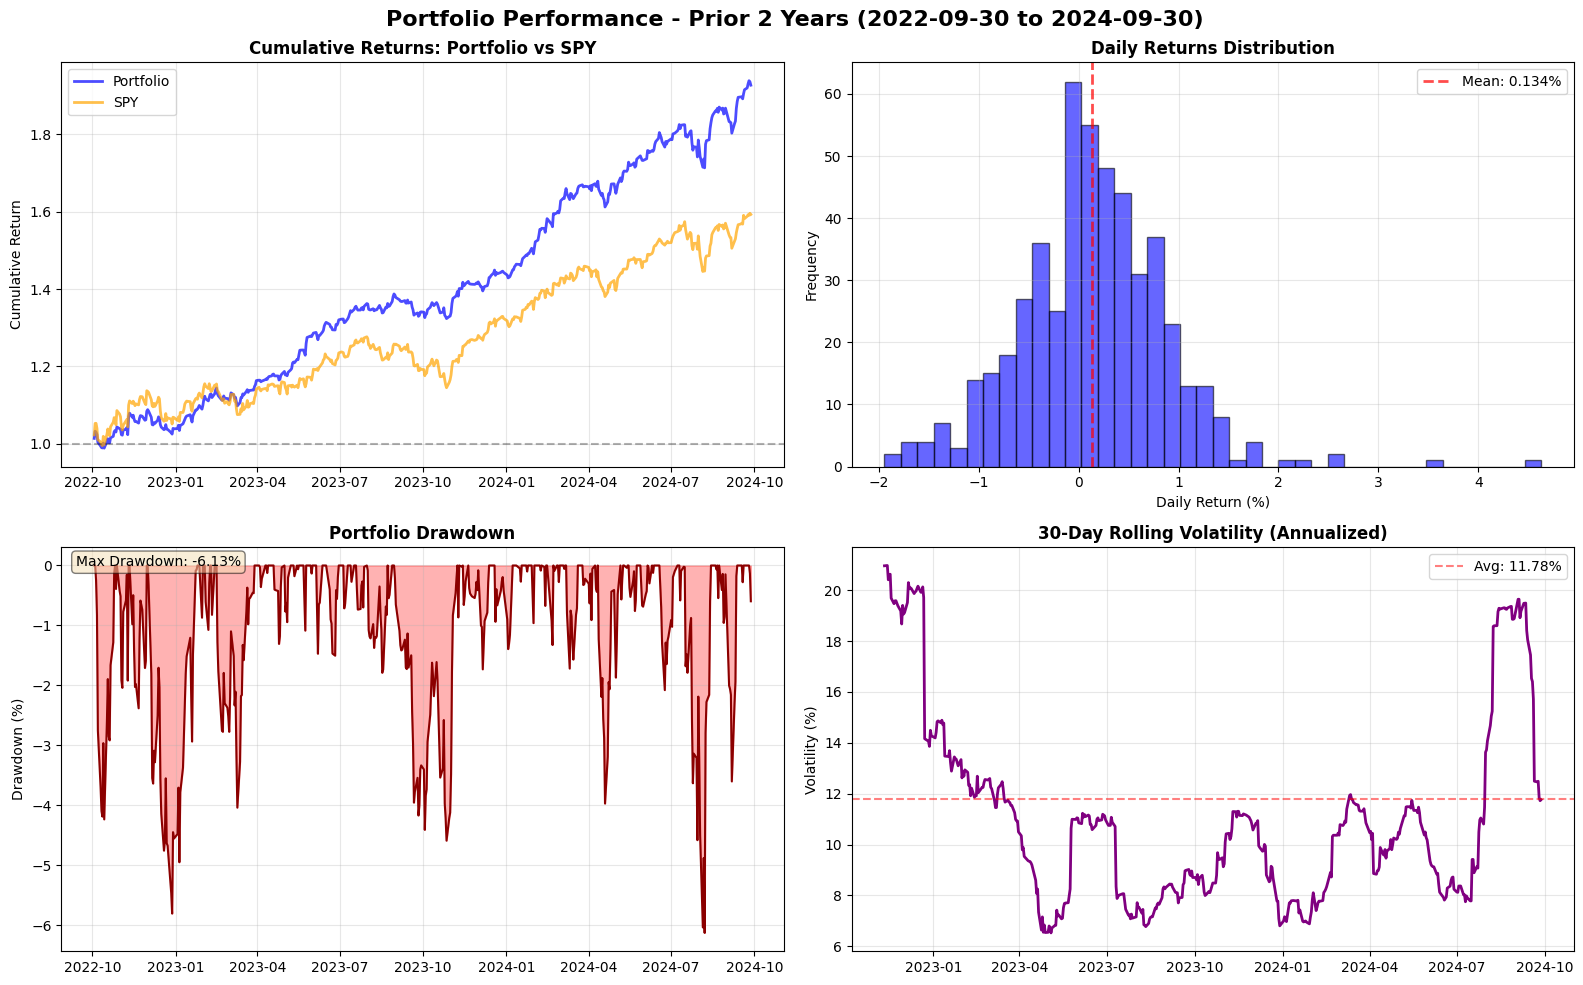

In [9]:
# Graph 2 years of portfolio returns BEFORE the start date
# Start date is 2024-09-30, so we want data from 2022-09-30 to 2024-09-30

prior_start_date = datetime(2022, 9, 30)
prior_end_date = datetime(2024, 9, 30)

prior_start_str = prior_start_date.strftime('%Y-%m-%d')
prior_end_str = prior_end_date.strftime('%Y-%m-%d')

print(f"Fetching 2 years of prior data: {prior_start_str} to {prior_end_str}")

# Fetch bulk price data for the prior period
prior_ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    prior_start_str, 
    prior_end_str, 
    frequency='daily'
)

print(f"Successfully fetched prior data for {len(prior_ticker_closes)} tickers\n")

# Calculate prior period returns
prior_ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(prior_ticker_closes[t])
    for t in weights if t in prior_ticker_closes
}

# Calculate portfolio daily returns for prior period
prior_portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    prior_ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics for prior period
prior_annualized_return = ReturnsCalculator.annualized_return(prior_portfolio_daily_returns, trading_days=252)
prior_annual_volatility = RiskCalculator.annualized_volatility(prior_portfolio_daily_returns, trading_days=252)
prior_sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    prior_portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha and beta vs SPY for prior period
if "SPY" in prior_ticker_closes:
    prior_spy_returns = ReturnsCalculator.daily_price_returns(prior_ticker_closes["SPY"])
    prior_alpha = PerformanceCalculator.alpha_jensen(
        prior_portfolio_daily_returns,
        prior_spy_returns,
        periods_per_year=252
    )
    prior_beta = RiskCalculator.beta(
        asset_daily_returns=prior_portfolio_daily_returns,
        market_daily_returns=prior_spy_returns
    )
else:
    prior_alpha = np.nan
    prior_beta = np.nan

# Print prior period metrics
print("=" * 60)
print("PRIOR PERIOD (2022-09-30 to 2024-09-30) PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {prior_annualized_return:>8.2%}")
print(f"Annual Volatility:     {prior_annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {prior_sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {prior_alpha:>8.2%}")
print(f"Beta vs SPY:           {prior_beta:>8.2f}")
print("=" * 60)

# Plot prior period cumulative returns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance - Prior 2 Years (2022-09-30 to 2024-09-30)', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs SPY
ax1 = axes[0, 0]
prior_portfolio_cumulative = (1 + prior_portfolio_daily_returns).cumprod()

ax1.plot(prior_portfolio_cumulative.index, prior_portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Portfolio', alpha=0.7)

if "SPY" in prior_ticker_closes:
    prior_spy_cumulative = (1 + prior_spy_returns).cumprod()
    aligned_spy = prior_spy_cumulative.reindex(prior_portfolio_cumulative.index).ffill()
    ax1.plot(prior_portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns: Portfolio vs SPY', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution
ax2 = axes[0, 1]
ax2.hist(prior_portfolio_daily_returns.dropna() * 100, bins=40, alpha=0.6, 
         color='blue', edgecolor='black')
ax2.axvline(prior_portfolio_daily_returns.mean() * 100, color='red', 
            linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {prior_portfolio_daily_returns.mean()*100:.3f}%')
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart
ax3 = axes[1, 0]
prior_running_max = prior_portfolio_cumulative.cummax()
prior_drawdown = (prior_portfolio_cumulative / prior_running_max - 1.0) * 100

ax3.fill_between(prior_drawdown.index, prior_drawdown.values, 0, 
                  alpha=0.3, color='red')
ax3.plot(prior_drawdown.index, prior_drawdown.values, linewidth=1.5, color='darkred')

ax3.set_title('Portfolio Drawdown', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
prior_max_dd = prior_drawdown.min()
ax3.text(0.02, 0.98, f'Max Drawdown: {prior_max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day)
ax4 = axes[1, 1]
prior_rolling_vol = prior_portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

ax4.plot(prior_rolling_vol.index, prior_rolling_vol.values, linewidth=2, color='purple')
ax4.axhline(y=prior_annual_volatility * 100, color='red', linestyle='--', alpha=0.5, 
            label=f'Avg: {prior_annual_volatility*100:.2f}%')
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()